In [1]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ipythonx/mvtec-ad/readme.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/license.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/readme.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/license.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/000_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/003_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/004_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/005_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/001_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/006_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/008_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/007_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/002_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/009_mask.png
/kaggle/in

# Module 4: Feature Extraction & Matching — SIFT
**Dataset:** MVTec AD — Wood category  
**Goal:** Extract SIFT keypoints & descriptors, match between image pairs, evaluate matching accuracy

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print('OpenCV version:', cv2.__version__)

OpenCV version: 4.13.0


## Helper: Load Image Paths

In [3]:
def load_image_paths(base_path, max_images=None):
    """
    Returns list of image paths from a folder (recursively).
    """
    image_paths = []
    for root, dirs, files in os.walk(base_path):
        for fname in files:
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(root, fname))
    if max_images:
        image_paths = image_paths[:max_images]
    return image_paths

## Load Sample Images (Good + Defect)

In [4]:
DATA_PATH = '/kaggle/input/datasets/ipythonx/mvtec-ad'

# Auto-detect all categories that have a test/good folder
ALL_CATEGORIES = sorted([
    d for d in os.listdir(DATA_PATH)
    if os.path.isdir(os.path.join(DATA_PATH, d, 'test', 'good'))
])
print(f'Found {len(ALL_CATEGORIES)} categories:')
for c in ALL_CATEGORIES:
    print(f'  - {c}')

# Pick first category for single-image demos below
CATEGORY = ALL_CATEGORIES[0]
good_paths   = load_image_paths(os.path.join(DATA_PATH, CATEGORY, 'test', 'good'))

# Pick first available defect type for this category
test_folder   = os.path.join(DATA_PATH, CATEGORY, 'test')
defect_types  = [d for d in os.listdir(test_folder) if d != 'good' and os.path.isdir(os.path.join(test_folder, d))]
defect_paths  = load_image_paths(os.path.join(test_folder, defect_types[0]))

print(f'\nDemo category : {CATEGORY}')
print(f'Defect type   : {defect_types[0]}')
print(f'Good images   : {len(good_paths)}')
print(f'Defect images : {len(defect_paths)}')


Found 15 categories:
  - bottle
  - cable
  - capsule
  - carpet
  - grid
  - hazelnut
  - leather
  - metal_nut
  - pill
  - screw
  - tile
  - toothbrush
  - transistor
  - wood
  - zipper

Demo category : bottle
Defect type   : contamination
Good images   : 20
Defect images : 21


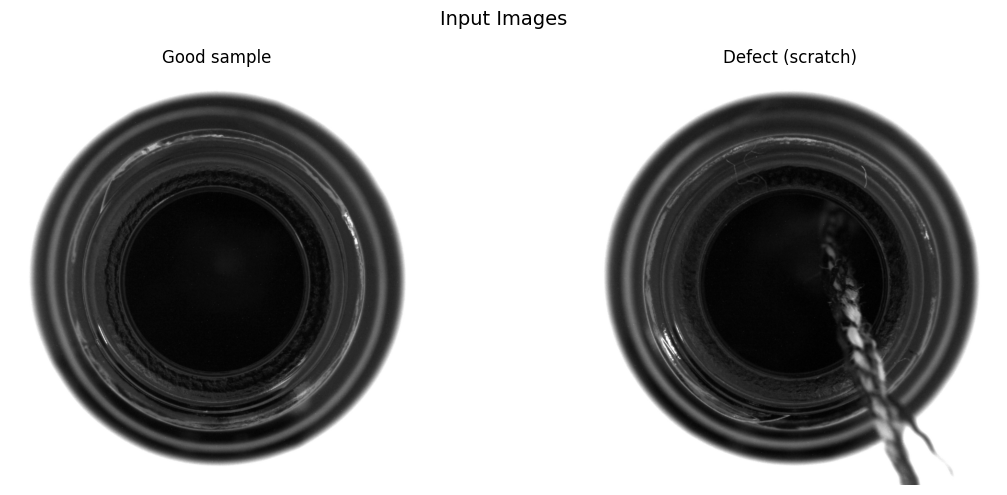

Good   shape: (900, 900)
Defect shape: (900, 900)


In [5]:
img_good_bgr   = cv2.imread(good_paths[0])
img_defect_bgr = cv2.imread(defect_paths[0])

gray_good   = cv2.cvtColor(img_good_bgr,   cv2.COLOR_BGR2GRAY)
gray_defect = cv2.cvtColor(img_defect_bgr, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(gray_good,   cmap='gray'); axes[0].set_title('Good sample');     axes[0].axis('off')
axes[1].imshow(gray_defect, cmap='gray'); axes[1].set_title('Defect (scratch)'); axes[1].axis('off')
plt.suptitle('Input Images', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Good   shape: {gray_good.shape}')
print(f'Defect shape: {gray_defect.shape}')

## SIFT: Extract Keypoints & Descriptors

In [6]:
def extract_sift(gray, n_features=0):
    """
    Extract SIFT keypoints and 128-D descriptors.
    Args:
        gray      : grayscale uint8 image
        n_features: max keypoints to keep (0 = all)
    Returns:
        keypoints, descriptors
    """
    sift = cv2.SIFT_create(nfeatures=n_features)
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    return keypoints, descriptors

In [7]:
kp_good,   desc_good   = extract_sift(gray_good)
kp_defect, desc_defect = extract_sift(gray_defect)

print(f'Good   → {len(kp_good)}   keypoints | descriptor shape: {desc_good.shape}')
print(f'Defect → {len(kp_defect)} keypoints | descriptor shape: {desc_defect.shape}')

Good   → 326   keypoints | descriptor shape: (326, 128)
Defect → 429 keypoints | descriptor shape: (429, 128)


## Visualize Keypoints

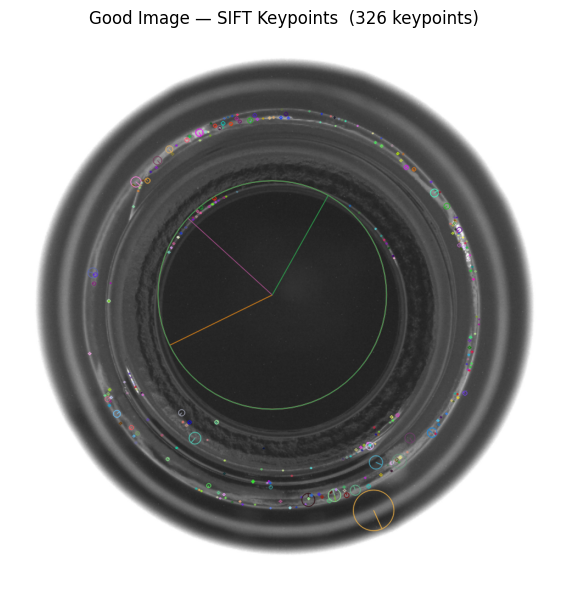

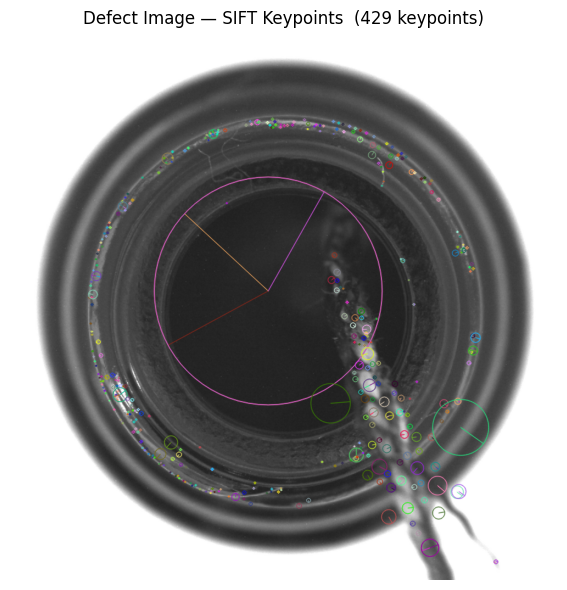

In [8]:
def draw_keypoints(gray, keypoints, title='SIFT Keypoints'):
    img_kp = cv2.drawKeypoints(
        gray, keypoints, None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    plt.figure(figsize=(8, 6))
    plt.title(f'{title}  ({len(keypoints)} keypoints)')
    plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

draw_keypoints(gray_good,   kp_good,   title='Good Image — SIFT Keypoints')
draw_keypoints(gray_defect, kp_defect, title='Defect Image — SIFT Keypoints')

## Feature Matching
### Brute-Force + Lowe's Ratio Test

In [9]:
def match_bf(desc1, desc2, ratio_thresh=0.75):
    """
    Brute-Force matching with Lowe's ratio test.
    Returns list of good DMatch objects.
    """
    if desc1 is None or desc2 is None:
        return []
    bf = cv2.BFMatcher(cv2.NORM_L2)
    raw = bf.knnMatch(desc1, desc2, k=2)
    good = [m for m, n in raw if m.distance < ratio_thresh * n.distance]
    return good


def draw_matches(gray1, kp1, gray2, kp2, matches, title='Matches', max_draw=50):
    matched_img = cv2.drawMatches(
        gray1, kp1, gray2, kp2,
        matches[:max_draw], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    plt.figure(figsize=(16, 6))
    plt.title(f'{title}  ({min(len(matches), max_draw)} shown / {len(matches)} total)')
    plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Good vs Good   → 15 matches


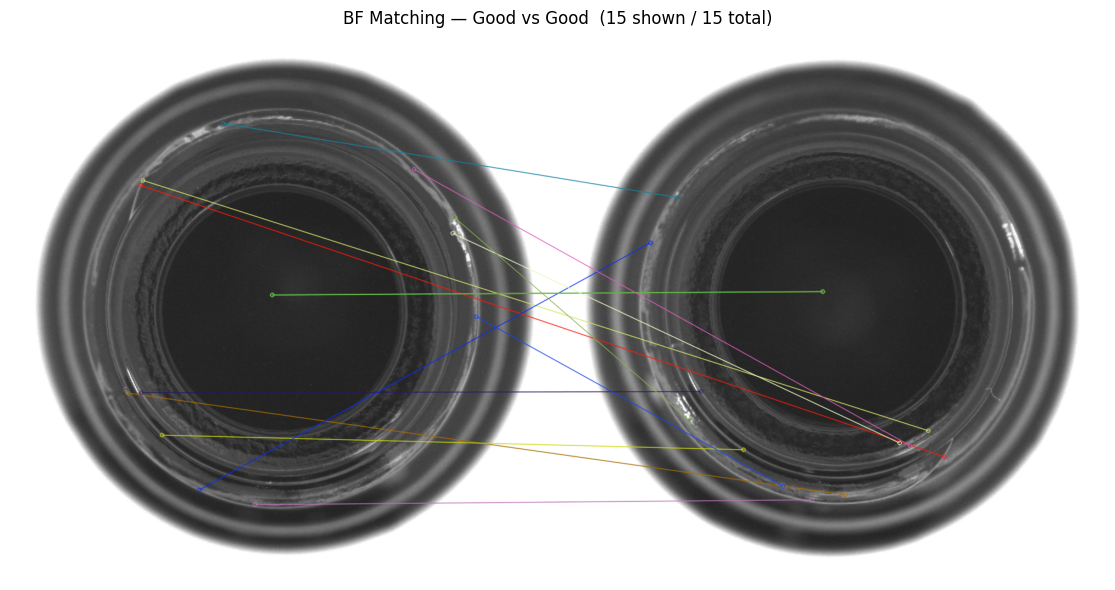

In [10]:
# Good vs Good (second good image)
img_good2_bgr = cv2.imread(good_paths[1])
gray_good2    = cv2.cvtColor(img_good2_bgr, cv2.COLOR_BGR2GRAY)
kp_good2, desc_good2 = extract_sift(gray_good2)

matches_gg = match_bf(desc_good, desc_good2)
print(f'Good vs Good   → {len(matches_gg)} matches')
draw_matches(gray_good, kp_good, gray_good2, kp_good2, matches_gg,
             title='BF Matching — Good vs Good')

Good vs Defect → 7 matches


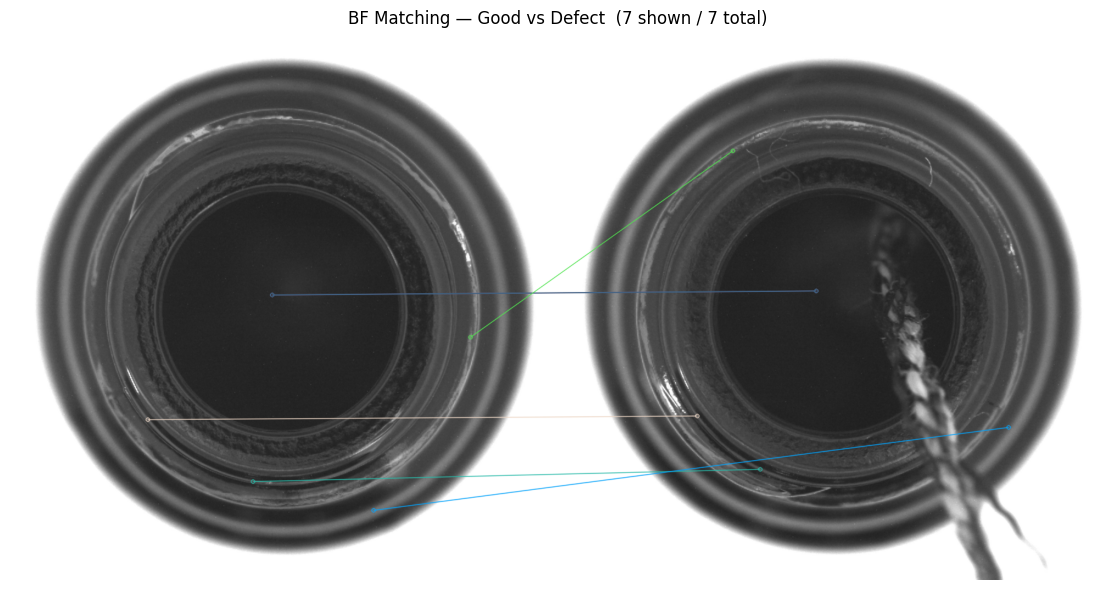

In [11]:
# Good vs Defect
matches_gd = match_bf(desc_good, desc_defect)
print(f'Good vs Defect → {len(matches_gd)} matches')
draw_matches(gray_good, kp_good, gray_defect, kp_defect, matches_gd,
             title='BF Matching — Good vs Defect')

### FLANN Matching

FLANN Good vs Defect → 7 matches


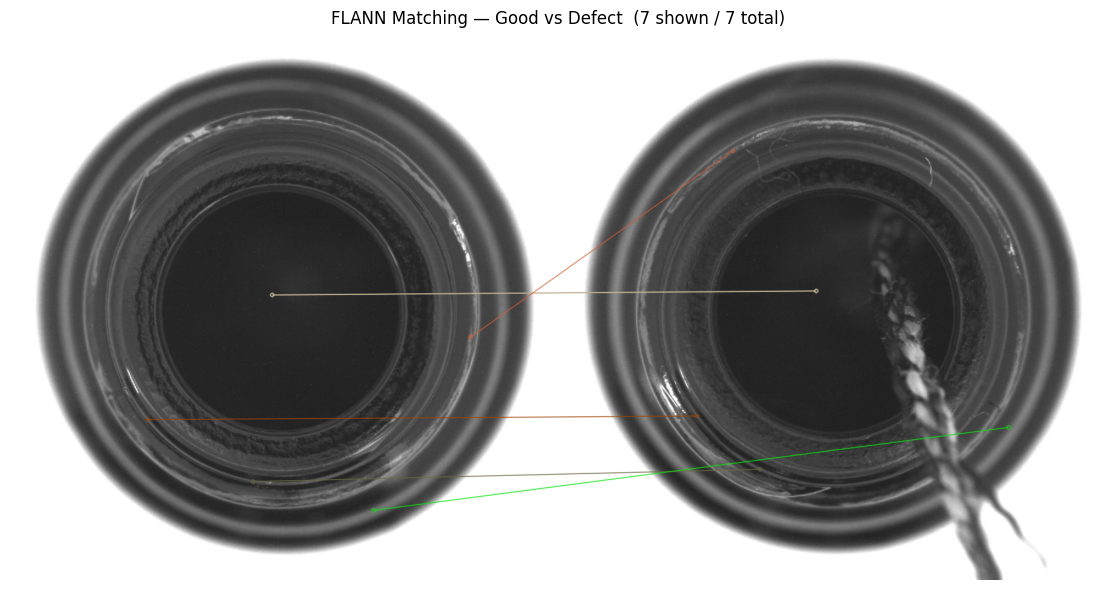

In [12]:
def match_flann(desc1, desc2, ratio_thresh=0.75):
    """
    FLANN-based matching with Lowe's ratio test (faster for large descriptor sets).
    """
    if desc1 is None or desc2 is None:
        return []
    index_params  = dict(algorithm=1, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    raw   = flann.knnMatch(np.float32(desc1), np.float32(desc2), k=2)
    good  = [m for m, n in raw if m.distance < ratio_thresh * n.distance]
    return good

matches_flann = match_flann(desc_good, desc_defect)
print(f'FLANN Good vs Defect → {len(matches_flann)} matches')
draw_matches(gray_good, kp_good, gray_defect, kp_defect, matches_flann,
             title='FLANN Matching — Good vs Defect')

## Effect of Ratio Threshold

 Ratio   Good-Good   Good-Defect
--------------------------------
  0.50           3             3
  0.65           8             6
  0.75          15             7
  0.85          52            42


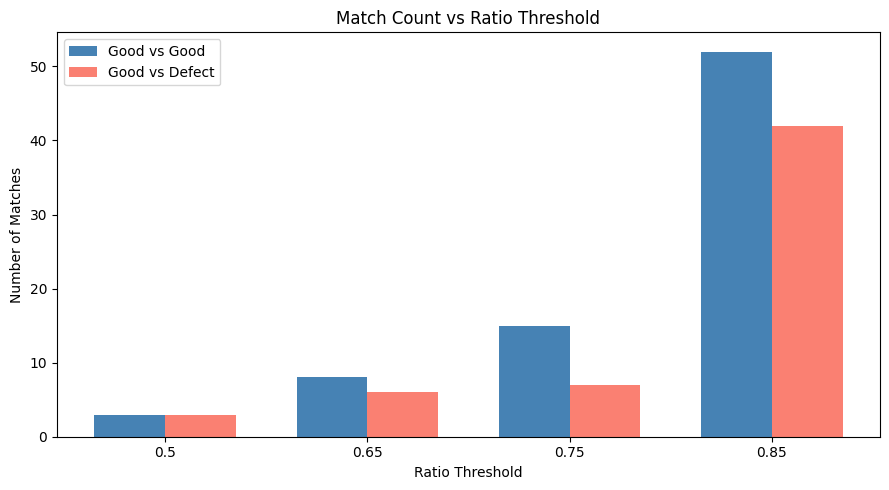

In [13]:
ratios = [0.5, 0.65, 0.75, 0.85]
gg_counts, gd_counts = [], []

print(f'{"Ratio":>6}  {"Good-Good":>10}  {"Good-Defect":>12}')
print('-' * 32)
for r in ratios:
    n_gg = len(match_bf(desc_good, desc_good2,  ratio_thresh=r))
    n_gd = len(match_bf(desc_good, desc_defect, ratio_thresh=r))
    gg_counts.append(n_gg)
    gd_counts.append(n_gd)
    print(f'{r:>6.2f}  {n_gg:>10}  {n_gd:>12}')

x = np.arange(len(ratios))
w = 0.35
plt.figure(figsize=(9, 5))
plt.bar(x - w/2, gg_counts, w, label='Good vs Good',   color='steelblue')
plt.bar(x + w/2, gd_counts, w, label='Good vs Defect', color='salmon')
plt.xticks(x, [str(r) for r in ratios])
plt.xlabel('Ratio Threshold')
plt.ylabel('Number of Matches')
plt.title('Match Count vs Ratio Threshold')
plt.legend()
plt.tight_layout()
plt.show()

## RANSAC Homography Verification

In [14]:
def compute_homography(kp1, kp2, matches, min_match=10):
    """
    Estimate homography via RANSAC to filter geometric outliers.
    Returns H matrix, inlier mask, number of inliers.
    """
    if len(matches) < min_match:
        print(f'Not enough matches ({len(matches)} < {min_match})')
        return None, None, 0
    src = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    n_inliers = int(mask.sum()) if mask is not None else 0
    return H, mask, n_inliers


H_gg, mask_gg, inliers_gg = compute_homography(kp_good, kp_good2,  matches_gg)
H_gd, mask_gd, inliers_gd = compute_homography(kp_good, kp_defect, matches_gd)

print(f'Good vs Good   → {len(matches_gg)} matches | RANSAC inliers: {inliers_gg}')
print(f'Good vs Defect → {len(matches_gd)} matches | RANSAC inliers: {inliers_gd}')

Not enough matches (7 < 10)
Good vs Good   → 15 matches | RANSAC inliers: 6
Good vs Defect → 7 matches | RANSAC inliers: 0


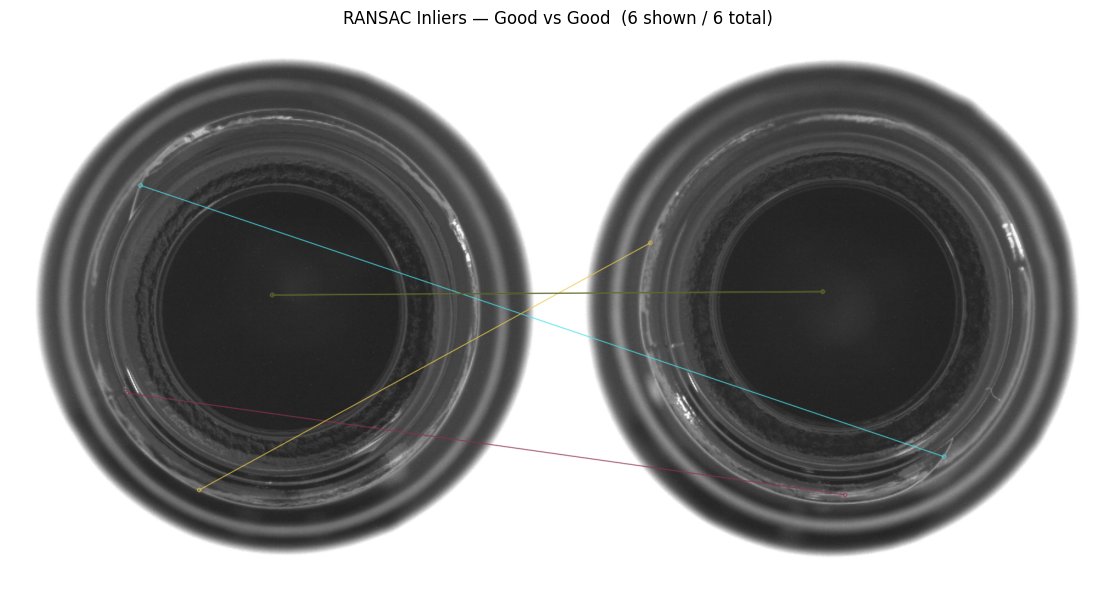

In [15]:
# Draw inlier matches only
if mask_gg is not None:
    inliers_gg_matches = [m for m, f in zip(matches_gg, mask_gg.ravel()) if f]
    draw_matches(gray_good, kp_good, gray_good2, kp_good2,
                 inliers_gg_matches, title='RANSAC Inliers — Good vs Good')

if mask_gd is not None:
    inliers_gd_matches = [m for m, f in zip(matches_gd, mask_gd.ravel()) if f]
    draw_matches(gray_good, kp_good, gray_defect, kp_defect,
                 inliers_gd_matches, title='RANSAC Inliers — Good vs Defect')

## Quantitative Metric — Match Score
**Match Score** = good matches after ratio test / keypoints in reference image.  
Higher score means the two images share more similar local features.

In [16]:
def match_score(n_matches, n_ref_keypoints):
    """Normalized match count: how many ref keypoints found a good match."""
    return n_matches / n_ref_keypoints if n_ref_keypoints > 0 else 0.0

score_gg = match_score(len(matches_gg), len(kp_good))
score_gd = match_score(len(matches_gd), len(kp_good))

print('=== Match Score (matches / ref keypoints) ===')
print(f'Good vs Good   : {len(matches_gg)} matches / {len(kp_good)} kp  →  score = {score_gg:.3f}')
print(f'Good vs Defect : {len(matches_gd)} matches / {len(kp_good)} kp  →  score = {score_gd:.3f}')
print()
print('Higher score → images share more similar local features (more similar texture/structure)')
print('Lower  score → images differ more (defect disturbs local features)')

=== Match Score (matches / ref keypoints) ===
Good vs Good   : 15 matches / 326 kp  →  score = 0.046
Good vs Defect : 7 matches / 326 kp  →  score = 0.021

Higher score → images share more similar local features (more similar texture/structure)
Lower  score → images differ more (defect disturbs local features)


## Batch Evaluation — Good vs All Defect Types

In [17]:
# ── Batch evaluation across ALL categories & ALL defect types ────────────────
all_results = {}   # { category: { defect_type: {mean, std} } }

for cat in ALL_CATEGORIES:
    test_dir = os.path.join(DATA_PATH, cat, 'test')
    g_paths  = load_image_paths(os.path.join(test_dir, 'good'))
    if not g_paths:
        continue

    # Use first good image as reference for this category
    ref_img  = cv2.imread(g_paths[0])
    ref_gray = cv2.cvtColor(ref_img, cv2.COLOR_BGR2GRAY)
    ref_kp, ref_desc = extract_sift(ref_gray)
    n_ref = len(ref_kp)

    cat_results = {}

    # Good baseline
    baseline_scores = []
    for p in g_paths[1:6]:
        img  = cv2.imread(p)
        if img is None: continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        kp, desc = extract_sift(gray)
        m = match_bf(ref_desc, desc)
        baseline_scores.append(match_score(len(m), n_ref))
    cat_results['good'] = {'mean': np.mean(baseline_scores), 'std': np.std(baseline_scores)}

    # Each defect type
    d_types = [d for d in os.listdir(test_dir)
               if d != 'good' and os.path.isdir(os.path.join(test_dir, d))]
    for dt in d_types:
        d_paths = load_image_paths(os.path.join(test_dir, dt))
        scores  = []
        for p in d_paths[:5]:
            img  = cv2.imread(p)
            if img is None: continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            kp, desc = extract_sift(gray)
            m = match_bf(ref_desc, desc)
            scores.append(match_score(len(m), n_ref))
        if scores:
            cat_results[dt] = {'mean': np.mean(scores), 'std': np.std(scores)}

    all_results[cat] = cat_results
    print(f'Done: {cat}')

print('\nBatch evaluation complete ✓')


Done: bottle
Done: cable
Done: capsule
Done: carpet
Done: grid
Done: hazelnut
Done: leather
Done: metal_nut
Done: pill
Done: screw
Done: tile
Done: toothbrush
Done: transistor
Done: wood
Done: zipper

Batch evaluation complete ✓


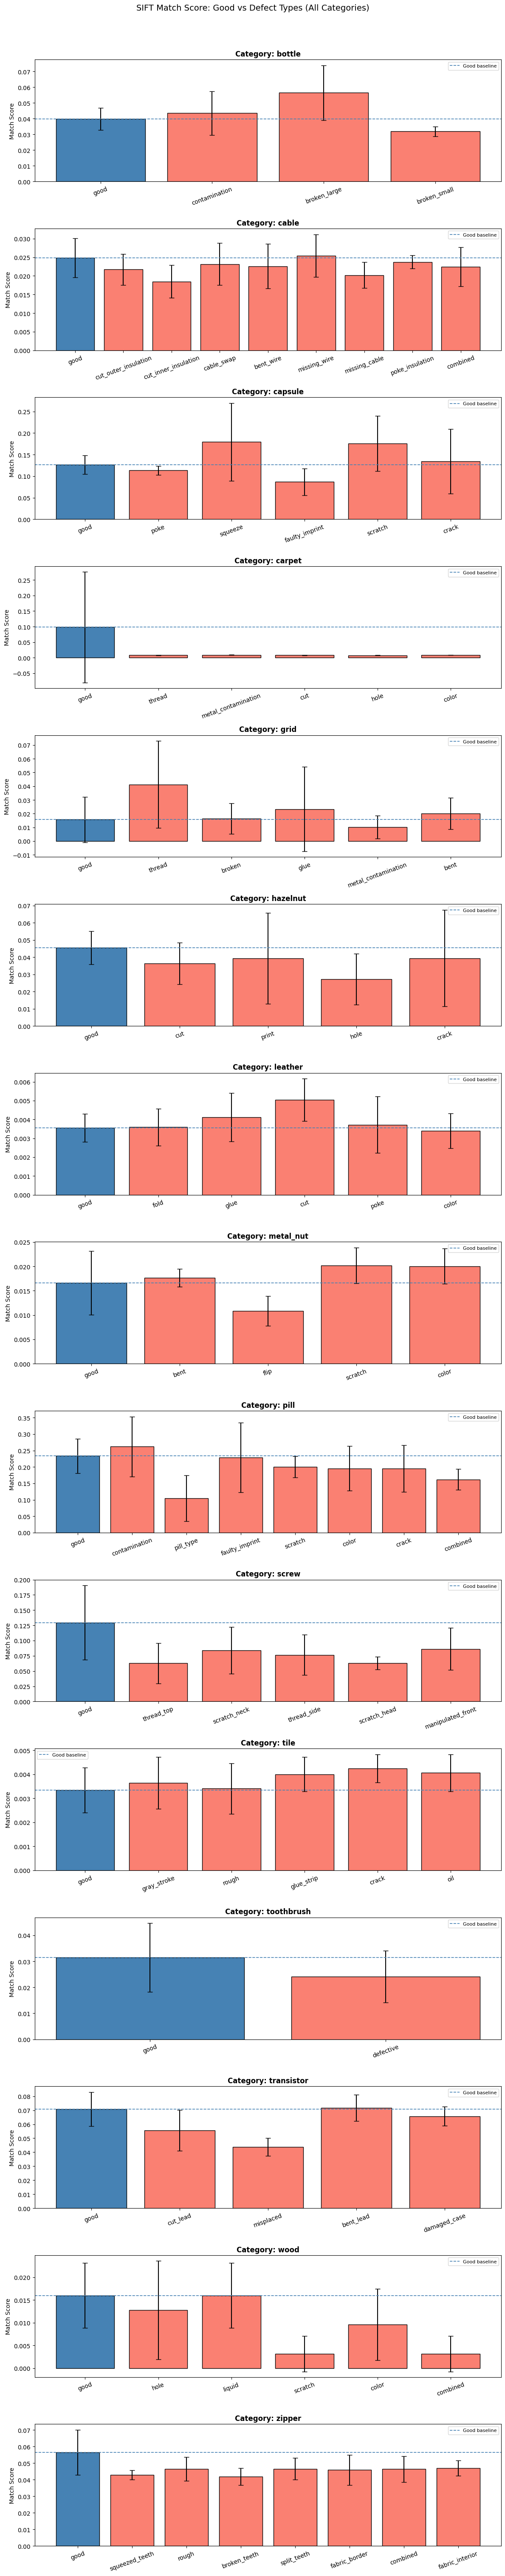

In [18]:
n_cats = len(all_results)
fig, axes = plt.subplots(n_cats, 1, figsize=(12, 4 * n_cats))
if n_cats == 1:
    axes = [axes]

for ax, (cat, cat_res) in zip(axes, all_results.items()):
    labels = list(cat_res.keys())
    means  = [cat_res[l]['mean'] for l in labels]
    stds   = [cat_res[l]['std']  for l in labels]
    colors = ['steelblue' if l == 'good' else 'salmon' for l in labels]

    ax.bar(labels, means, yerr=stds, capsize=4, color=colors, edgecolor='black')
    ax.axhline(y=cat_res['good']['mean'], color='steelblue',
               linestyle='--', linewidth=1.2, label='Good baseline')
    ax.set_title(f'Category: {cat}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Match Score')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=8)

plt.suptitle('SIFT Match Score: Good vs Defect Types (All Categories)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Summary

| Step | What was done |
|------|---------------|
| Extraction | SIFT keypoints + 128-D descriptors via `cv2.SIFT_create()` |
| Matching | Brute-Force and FLANN, both with Lowe's ratio test |
| Verification | RANSAC homography to filter geometric outliers |
| Metric | **Inlier Ratio** = RANSAC inliers / ratio-test matches |
| Finding | Good–Good pairs yield higher inlier ratio than Good–Defect pairs |